# **Airline Passenger**

### Contexte et objectif du Projet
Dans un contexte où la concurrence est rude entre les compagnies aériennes, comprendre les schémas de voyage des passagers est crucial.

Ce projet vise à **prédire l'évolution de nombre de voyageurs d'une compagnie, pour l'aider à optimiser ses opérations et à anticiper la demande**.

### Dictionnaire des données
Colonnes :
* **Month** → Informations sur la date (fréquence mensuelle)
* **total_passengers** → Nombre total de passagers

## **1. Imports & configuration**

---



In [1]:
%pip install pandas numpy matplotlib seaborn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install scikit-learn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Chargement des données**

---



In [4]:
data = pd.read_csv("/workspaces/Airline-Passenger/data/airline-passengers.csv")

In [5]:
# Affichons les données de la 1ere année de cette période de 12 ans
data.head(12)

,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


In [6]:
# Affichons les données de la dernière année de cette période de 12 ans
data.tail(12)

,month,total_passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461


## **3. Analyse Exploratoire des données**

---



### **3.1 Inspection basique**

In [7]:
# Inspection générale des données
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   month             144 non-null    str  
 1   total_passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


Notre data a pour dimension **144 lignes** et **2 colonnes**.
On constate que l'on n'a aucune valeurs manquantes. Les données de *'total_passengers'* sont de type **int64** et ceux de *'month'* sont de type **object**.

In [8]:
data_duplicate = data.duplicated().sum()
print(f'Nous avons {data_duplicate} valeurs dupliquées.')

Nous avons 0 valeurs dupliquées.


In [9]:
# Stat de base
data.describe().T

,count,mean,std,min,25%,50%,75%,max
total_passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


* Le nombre moyen de passagers par mois sur la période observée est d'environ **280,3**.
* Avec un intervalle **[min, max] = [104, 622]** et une médiane autour de **265.5**.
* L'écart type est d'environ **119,97**, ce qui indique une variabilité significative du nombre de passagers.

### **3.2 Évolution du nombre de passagers par an**

In [10]:
data['month'] = pd.to_datetime(data['month'])   # Transformation de la colonne mois et données temporelles
data['year'] = data['month'].dt.year            # Extraction du temps uniquement
annual_passengers = data.groupby('year')['total_passengers'].sum()

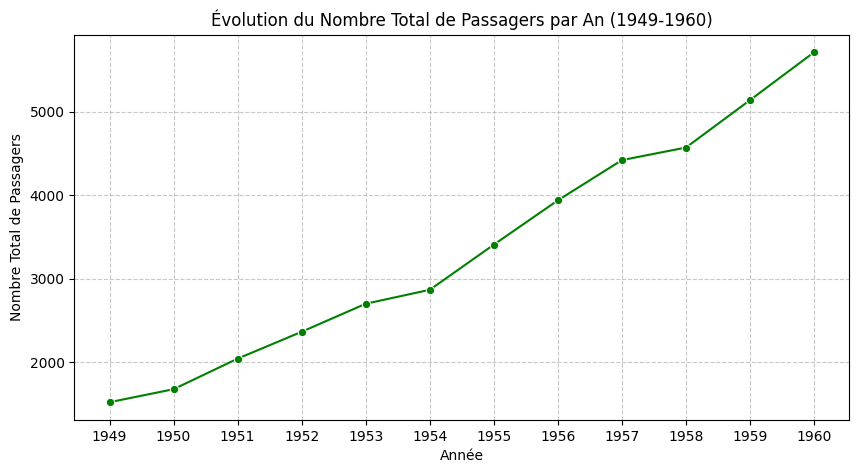

In [11]:
# Affichons nos données
plt.figure(figsize=(10, 5))
sns.lineplot(x=annual_passengers.index, y=annual_passengers.values, marker='o', color='green')
plt.title('Évolution du Nombre Total de Passagers par An (1949-1960)')
plt.xlabel('Année')
plt.ylabel('Nombre Total de Passagers')
plt.xticks(annual_passengers.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **3.3 Évolution mensuelle des passagers pour chaque année**

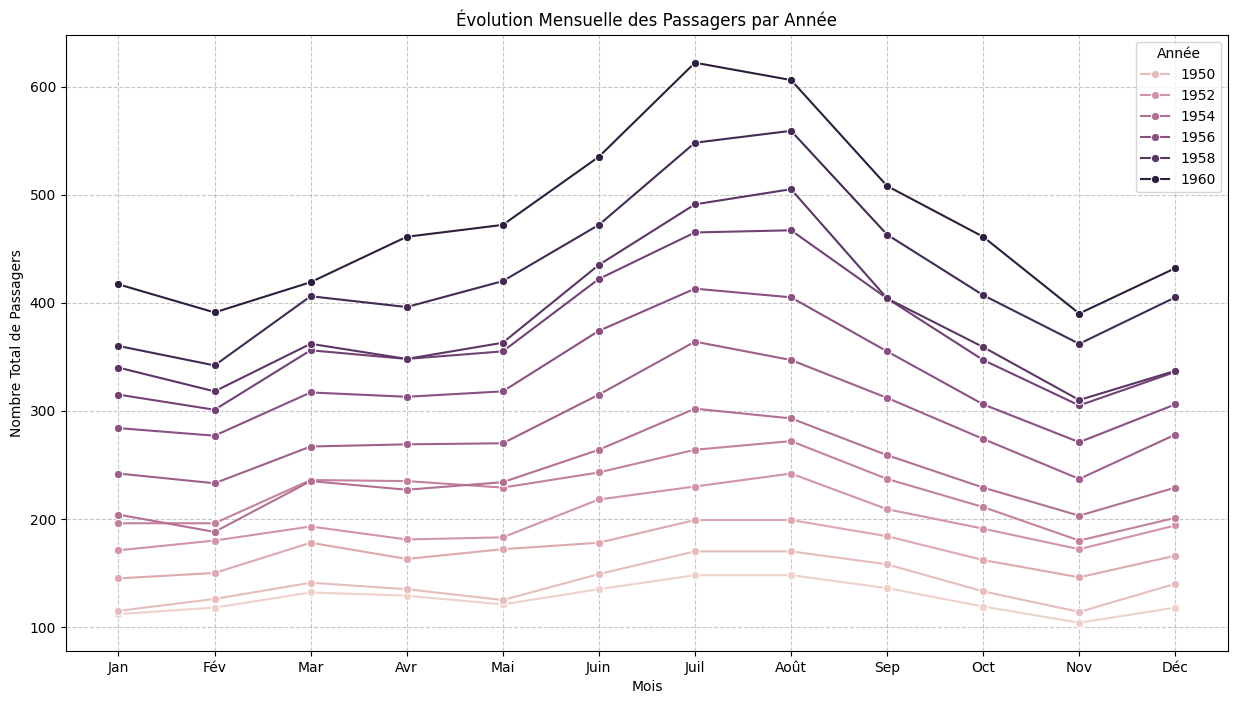

In [12]:
# Affichons nos données
plt.figure(figsize=(15, 8))
sns.lineplot(data=data, x=data['month'].dt.month, y='total_passengers', hue='year', marker='o')
plt.title('Évolution Mensuelle des Passagers par Année')
plt.xlabel('Mois')
plt.ylabel('Nombre Total de Passagers')
plt.xticks(range(1, 13), ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Année')
plt.show()

### **3.4 Évolution du nombre de passagers par saison**

In [13]:
# Définissons nos saisons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Hiver'
    elif month in [3, 4, 5]:
        return 'Printemps'
    elif month in [6, 7, 8]:
        return 'Été'
    else: # 9, 10, 11
        return 'Automne'

# Colonne saison dans nos données
data['season'] = data['month'].dt.month.apply(get_season)

seasonal_passengers = data.groupby(['year', 'season'])['total_passengers'].sum().reset_index()

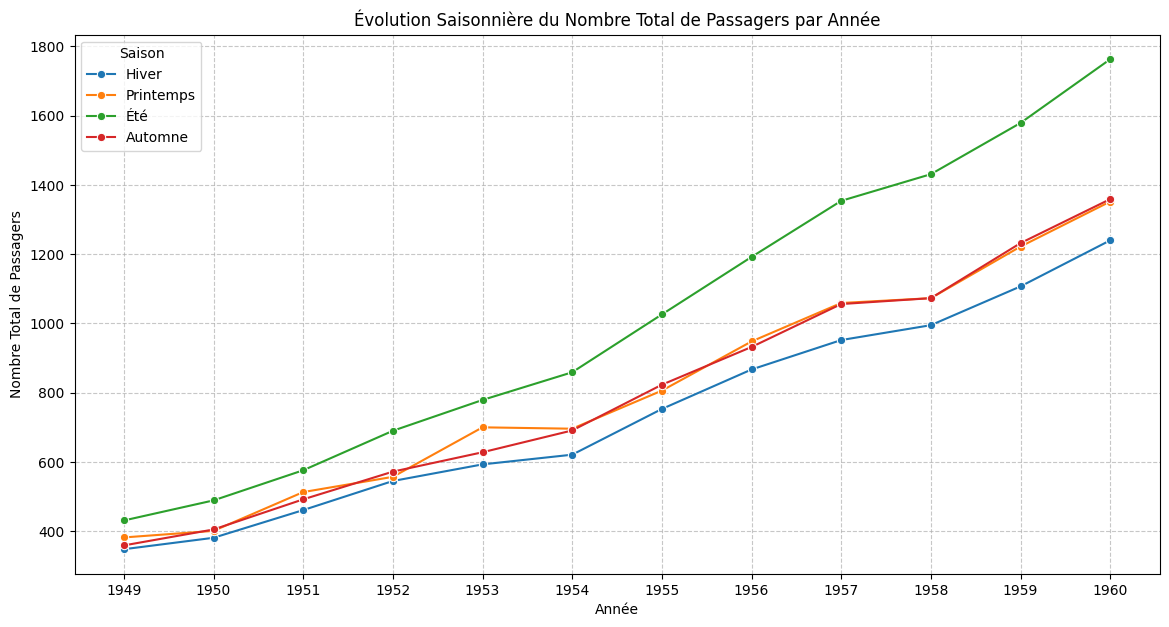

In [14]:
season_order = ['Hiver', 'Printemps', 'Été', 'Automne']
seasonal_passengers['season'] = pd.Categorical(seasonal_passengers['season'], categories=season_order, ordered=True)
seasonal_passengers = seasonal_passengers.sort_values(['year', 'season'])


plt.figure(figsize=(14, 7))
sns.lineplot(data=seasonal_passengers, x='year', y='total_passengers', hue='season', marker='o')
plt.title('Évolution Saisonnière du Nombre Total de Passagers par Année')
plt.xlabel('Année')
plt.ylabel('Nombre Total de Passagers')
plt.xticks(seasonal_passengers['year'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Saison')
plt.show()

*   **Croissance Annuelle Soutenue :** Le nombre total de passagers a affiché une croissance constante et significative d'année en année.
*   **Saisonnalité Mensuelle Prononcée :** Chaque année, on observe une forte saisonnalité mensuelle, avec un pic systématique des passagers durant les mois d'été (juillet-août), suivi d'une baisse en automne et en hiver.
*   **Performance Saisonnière Inégale :** L'été est clairement la saison la plus fréquentée, enregistrant le plus grand nombre de passagers, tandis que l'hiver est son opposé. Le printemps et l'automne se situent comme saisons intermédiaires.
*   **Tendance Haussière Généralisée :** Indépendamment de la saison, toutes les périodes de l'année ont connu une augmentation du nombre de passagers au fil des ans, ce qui confirme une tendance globale à la hausse du trafic aérien.

## **4. Pré-traitement des données**

---


### **4.1 Définir l'index temporel**

## **Bibliographie**

* [Analyse des séries temporelles](https://fr.mathworks.com/discovery/time-series-analysis.html)
* [Qu’est-ce qu’un modèle de séries temporelles ?](https://www.ibm.com/fr-fr/think/topics/time-series-model)